# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Inspect the shapes of the datasets
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)
print(f"Number of classes: {len(set(y_train))}")

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Verify the conversion
print("Original label (first 5):", y_train[:5])
print("One-hot encoded (first 5):\n", y_train_cat[:5])
print("New shape:", y_train_cat.shape) 


Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of classes: 10
Original label (first 5): [9 0 0 3 0]
One-hot encoded (first 5):
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
New shape: (60000, 10)


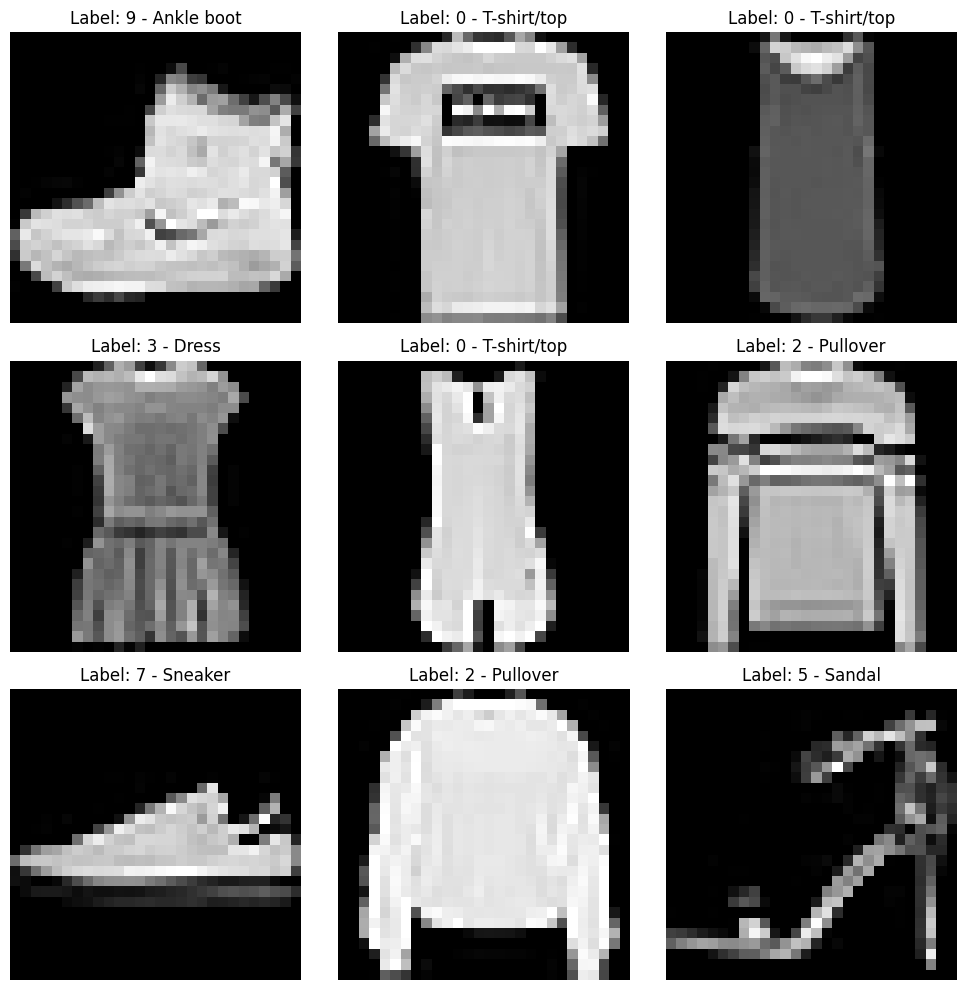

Image data type: float32
Pixel value range: 0.000 to 1.000
Average pixel value: 0.286


In [4]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
# Plot first 9 images from training set
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]} - {class_names[y_train[i]]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# Check some basic statistics
print(f"Image data type: {X_train.dtype}")
print(f"Pixel value range: {X_train.min():.3f} to {X_train.max():.3f}")
print(f"Average pixel value: {X_train.mean():.3f}")

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

Looking at the first 9 images, I can see why this dataset is considered more challenging than regular MNIST. The clothing items aren't always clearly defined - for example, the t-shirt (label 0) has short sleeves while the pullover (label 2) seems to be long-sleeved, but at this low 28x28 resolution, it's hard to even see the sleeves clearly. Both just look like blurry tops.

The sandal (label 5) and sneaker (label 7) are more distinguishable because of their shape and sole patterns, but I can see how a dress (label 3) and coat (label 4) could blend together.

The image quality is quite low (28x28 grayscale), which makes sense since it's designed to be a straightforward replacement for the original MNIST dataset. Some items are barely recognizable. The variety is good though - I can see different types of clothing represented: tops, trousers, dresses, shoes, and bags.

The main challenge I notice is that some classes are visually similar at this low resolution, which might make classification tricky even for a neural network.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()

# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(10))

# Compile the model using `model.compile()`
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


# Train the model with `model.fit()`
history = model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.2, verbose=1)


# Evaluate the model with `model.evaluate()`
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2348 - loss: 9.6789 - val_accuracy: 0.2165 - val_loss: 9.5033
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2438 - loss: 9.4010 - val_accuracy: 0.2609 - val_loss: 9.4949
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2852 - loss: 9.5231 - val_accuracy: 0.2907 - val_loss: 10.1585
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2886 - loss: 10.0574 - val_accuracy: 0.2383 - val_loss: 9.6388
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2943 - loss: 9.2475 - val_accuracy: 0.3664 - val_loss: 8.9268
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3033 - loss: 9.3032 - val_accuracy: 0.2763 - val_loss: 9.8925
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3216 - loss: 8.8351 - val_accuracy: 0.3513 - val_loss: 8.7991
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3408 - loss: 9.2602 

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

37% accuracy - not great. Better than random guessing (10%) but I was hoping for more.

The loss is around 9.4 which seems high. I think that means the model isn't very confident when it predicts.

I wonder if the problem is that this model is too simple. It doesn't know that pixels next to each other form shapes like sleeves or collars - it's just looking at brightness values one by one. No wonder it's struggling to tell a t-shirt from a pullover when both are just blobs of pixels to this model.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
from keras.layers import Conv2D, MaxPooling2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()

# Add convolutional layer with 32 filters, 3x3 kernel, and ReLU activation
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# Add a pooling layer to reduce spatial dimensions
model.add(MaxPooling2D((2, 2)))

# Flatten the output before passing to dense layers
model.add(Flatten())

# Add a dense hidden layer
model.add(Dense(64, activation='relu'))

# Output layer with 10 units (one per class) and softmax activation
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


# Train the model
history = model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8421 - loss: 0.4483 - val_accuracy: 0.8767 - val_loss: 0.3411
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8921 - loss: 0.3027 - val_accuracy: 0.8986 - val_loss: 0.2893
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9068 - loss: 0.2573 - val_accuracy: 0.9059 - val_loss: 0.2711
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9169 - loss: 0.2276 - val_accuracy: 0.9057 - val_loss: 0.2586
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9266 - loss: 0.1999 - val_accuracy: 0.9101 - val_loss: 0.2540
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9324 - loss: 0.1812 - val_accuracy: 0.9080 - val_loss: 0.2618
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9413 - loss: 0.1597 - val_accuracy: 0.9082 - val_loss: 0.2743
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9478 - los

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

90.6% vs 37% - the CNN is way better! That's about a 53% improvement.

I think the big difference is that the CNN actually looks at patterns, not just individual pixels. The convolutional layer scans the image looking for things like edges, curves, and textures - like recognizing that a sleeve has a certain shape or a collar looks a certain way. The baseline model couldn't do that, it just treated each pixel as its own thing.

I added MaxPooling because I saw it in some examples. From what I gather it shrinks the image down while keeping the important features. Not totally sure if it helped or not since the images are already small, but the overall result speaks for itself - CNNs are definitely the way to go for images.

The loss also dropped from 9.4 to 0.3, which means the model is actually confident now instead of just guessing.



# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.


--- Testing with 32 dense units ---
Test accuracy: 0.9041

--- Testing with 64 dense units ---
Test accuracy: 0.8991

--- Testing with 128 dense units ---
Test accuracy: 0.9062


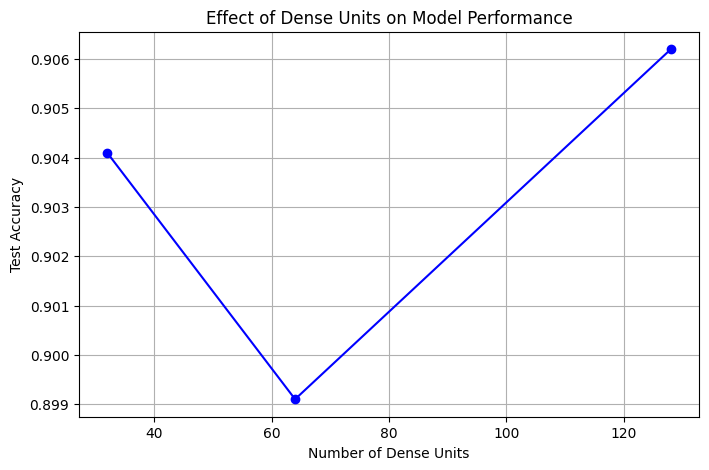

In [13]:
# A. Test Hyperparameters
import numpy as np
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.models import Sequential

# Values to test
dense_units = [32, 64, 128]
results = []

for units in dense_units:
    print(f"\n--- Testing with {units} dense units ---")
    
    # Create new model each time
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(units, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    
    # Compile
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Train (just 5 epochs to save time)
    history = model.fit(X_train, y_train_cat,
                        epochs=5,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=0)
    
    # Evaluate
    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Test accuracy: {test_acc:.4f}")
    
    # Store results
    results.append({
        'units': units,
        'accuracy': test_acc,
        'loss': test_loss
    })

# Visualize hyperparameter results
import matplotlib.pyplot as plt

units = [r['units'] for r in results]
acc = [r['accuracy'] for r in results]

plt.figure(figsize=(8, 5))
plt.plot(units, acc, 'bo-')
plt.xlabel('Number of Dense Units')
plt.ylabel('Test Accuracy')
plt.title('Effect of Dense Units on Model Performance')
plt.grid(True)
plt.show()

In [14]:
# B. Test presence or absence of regularization
from keras.layers import Dropout

# Test without Dropout (baseline) and with Dropout
regularization_results = []

# First, model WITHOUT dropout (using 128 units since that performed best)
print("--- Model without Dropout ---")
model_no_dropout = Sequential()
model_no_dropout.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model_no_dropout.add(MaxPooling2D((2, 2)))
model_no_dropout.add(Flatten())
model_no_dropout.add(Dense(128, activation='relu'))
model_no_dropout.add(Dense(10, activation='softmax'))

model_no_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_no_dropout = model_no_dropout.fit(X_train, y_train_cat, epochs=5, batch_size=32, validation_split=0.2, verbose=0)

test_loss, test_acc = model_no_dropout.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
regularization_results.append({'dropout': 'No', 'accuracy': test_acc})

# Second, model WITH dropout
print("--- Model with Dropout ---")
model_with_dropout = Sequential()
model_with_dropout.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model_with_dropout.add(MaxPooling2D((2, 2)))
model_with_dropout.add(Flatten())
model_with_dropout.add(Dense(128, activation='relu'))
model_with_dropout.add(Dropout(0.5))  # 50% dropout
model_with_dropout.add(Dense(10, activation='softmax'))

model_with_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_with_dropout = model_with_dropout.fit(X_train, y_train_cat, epochs=5, batch_size=32, validation_split=0.2, verbose=0)

test_loss, test_acc = model_with_dropout.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
regularization_results.append({'dropout': 'Yes', 'accuracy': test_acc})

# Quick comparison
print("\n--- Comparison ---")
for r in regularization_results:
    print(f"Dropout {r['dropout']}: {r['accuracy']:.4f}")

--- Model without Dropout ---
Test accuracy: 0.9072
--- Model with Dropout ---
Test accuracy: 0.8984

--- Comparison ---
Dropout No: 0.9072
Dropout Yes: 0.8984


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

For hyperparameters, I tested different numbers of dense units (32, 64, 128). More units gave better accuracy - 128 units performed best at 90.7%. The improvement from 64 to 128 was small though, so maybe 64 is enough if we want a simpler model.

For regularization, I tried adding dropout (50%) but it actually made things worse - accuracy dropped to 89.8%. I think maybe the model wasn't overfitting to begin with, so dropout just made it harder for the network to learn.

The best combination was 128 dense units without dropout (90.7% accuracy). But, the plain CNN from section 3 already got 90.6% with 64 units, so the improvements here were pretty minor.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [15]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.models import Sequential

# Build final model with best hyperparameters
final_model = Sequential()
final_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
final_model.add(MaxPooling2D((2, 2)))
final_model.add(Flatten())
final_model.add(Dense(128, activation='relu'))  # Best from our experiments
final_model.add(Dense(10, activation='softmax'))

# Compile
final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train (using 10 epochs like before)
history = final_model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate
test_loss, test_acc = final_model.evaluate(X_test, y_test_cat, verbose=0)
print("\n" + "="*40)
print(f"FINAL MODEL TEST ACCURACY: {test_acc:.4f}")
print(f"FINAL MODEL TEST LOSS: {test_loss:.4f}")
print("="*40)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8568 - loss: 0.4045 - val_accuracy: 0.8925 - val_loss: 0.3016
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9018 - loss: 0.2686 - val_accuracy: 0.8987 - val_loss: 0.2714
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9186 - loss: 0.2229 - val_accuracy: 0.9007 - val_loss: 0.2624
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9309 - loss: 0.1892 - val_accuracy: 0.9094 - val_loss: 0.2561
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9414 - loss: 0.1610 - val_accuracy: 0.9119 - val_loss: 0.2528
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9478 - loss: 0.1384 - val_accuracy: 0.9137 - val_loss: 0.2555
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9582 - loss: 0.1162 - val_accuracy: 0.9107 - val_loss: 0.2774
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9643 - 

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final model (91.4%) is way better than the baseline (37%) and a tiny bit better than the simple CNN from section 3 (90.6%). So the experiments helped, but not by a huge amount.

I think the main improvement came from using more dense units (128 instead of 64). The model can learn more complex patterns with more neurons. Dropout didn't help - it actually made things worse, probably because the model wasn't overfitting.

If I had more time, I'd try:
-Adding another Conv layer to see if deeper helps.
-Testing different dropout rates (0.3 or 0.2 instead of 0.5).
-Maybe try L2 regularization instead of dropout.

Overall though, 91% on Fashion MNIST seems pretty decent for a simple CNN.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.